In [37]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, f1_score

## Exploratory Data Analysis

In [38]:
df = pd.read_csv('dataset.csv')

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [39]:
df.rename(columns={
    'N': 'nitrogen',
    'P': 'phosphorus',
    'K': 'potassium',
    }, inplace=True)

df.head()

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


- Nitrogen: mg/kg
- Potassium: mg/kg
- Phosporus: mg/kg
- Temperature: Celcius
- Humidity
- pH
- Rainfall: per month in mm

In [40]:
df.info()

df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9324 entries, 0 to 9323
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nitrogen     9324 non-null   int64  
 1   phosphorus   9324 non-null   int64  
 2   potassium    9324 non-null   int64  
 3   temperature  9324 non-null   float64
 4   humidity     9324 non-null   float64
 5   ph           9324 non-null   float64
 6   rainfall     9324 non-null   float64
 7   label        9324 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 582.9+ KB


,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
count,9324.000000,9324.000000,9324.000000,9324.000000,9324.000000,9324.000000,9324.000000,9324
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rice
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,476
mean,55.885993,52.454848,43.725547,26.496638,72.413670,6.578284,103.283951,NaN
std,37.190518,29.925679,42.965660,5.352988,22.916171,0.793327,56.163347,NaN
min,0.000000,4.000000,5.000000,8.825675,14.258040,3.504752,5.314507,NaN
25%,25.000000,29.000000,21.000000,23.338494,60.445305,6.078439,63.835498,NaN
50%,43.000000,51.000000,32.000000,26.600190,81.017834,6.542777,93.172220,NaN
75%,90.000000,68.000000,48.000000,29.502934,90.297518,7.033908,130.379712,NaN


In [41]:
missing_rate = df.isna().mean().sort_values(ascending=False).round(4)

print(missing_rate)

nitrogen       0.0
phosphorus     0.0
potassium      0.0
temperature    0.0
humidity       0.0
ph             0.0
rainfall       0.0
label          0.0
dtype: float64


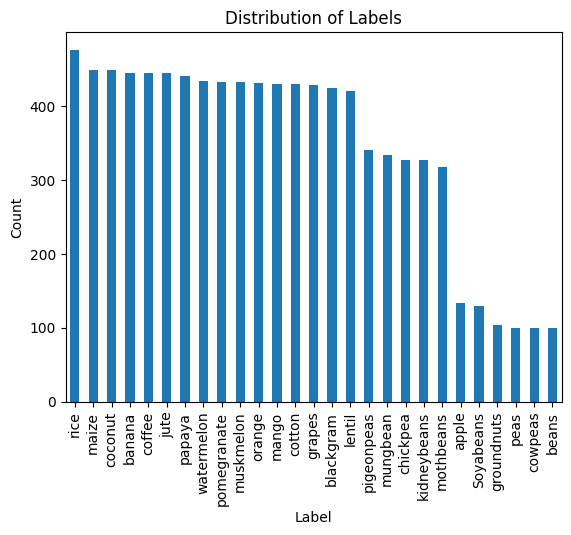

In [42]:
df["label"].value_counts().plot(kind="bar")
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels")
plt.show()

In [43]:
dup_rate = df.duplicated().mean()
df.drop_duplicates()

print(dup_rate)

0.00010725010725010725


In [44]:
total_labels = df["label"].nunique()
print(f"Total unique labels: {total_labels}")

Total unique labels: 27


## Feature Engineering

In [45]:
# df['npk_total'] = df['nitrogen'] + df['phosphorus'] + df['potassium']
# df["npk_product"] = df["nitrogen"] * df["phosphorus"] * df["potassium"]

# df['n_p_ratio'] = df['nitrogen'] / (df['phosphorus'] + 1e-6)
# df['n_k_ratio'] = df['nitrogen'] / (df['potassium'] + 1e-6)
# df['p_k_ratio'] = df['phosphorus'] / (df['potassium'] + 1e-6)

# df["temp_humidity"] = df["temperature"] * df["humidity"]
# df["humidity_rain_ratio"] = df["humidity"] / (df["rainfall"] + 1e-6)

# df["ph_deviation"] = abs(df["ph"] - 7)

# df['ph_acidic']   = (df['ph'] < 6.0).astype(int)
# df['ph_neutral']  = ((df['ph'] >= 6.0) & (df['ph'] <= 7.5)).astype(int)
# df['ph_alkaline'] = (df['ph'] > 7.5).astype(int)

df.head()

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


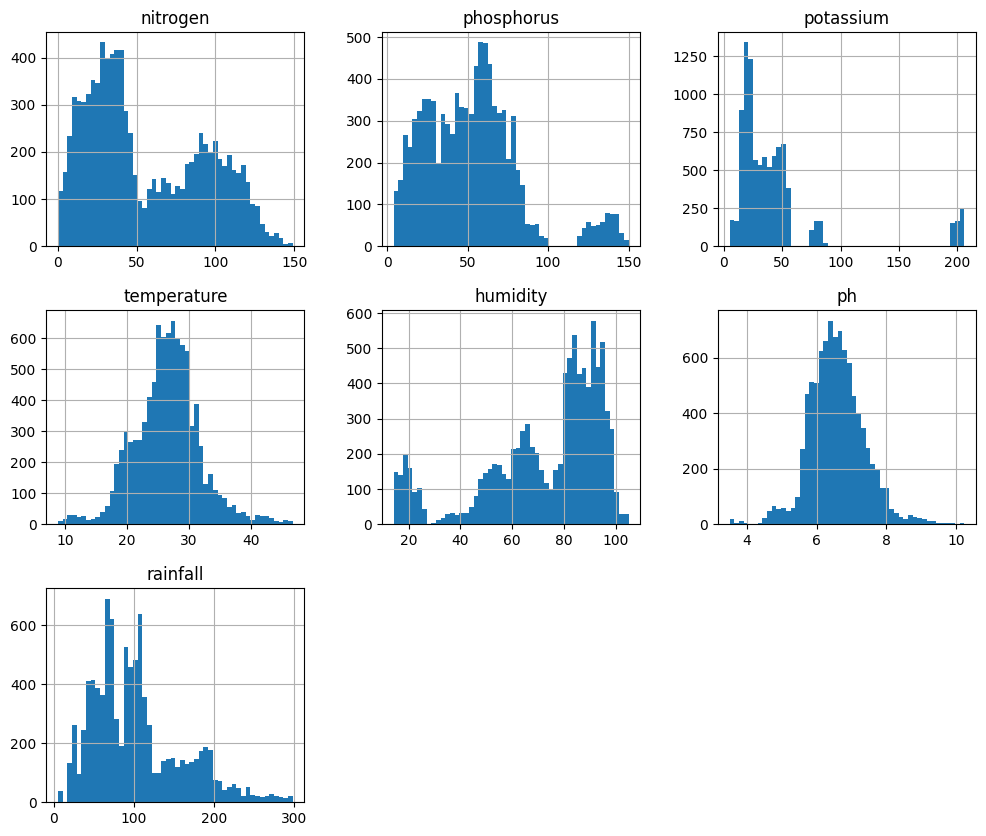

In [46]:
df.hist(bins=50, figsize=(12,10))
plt.show()

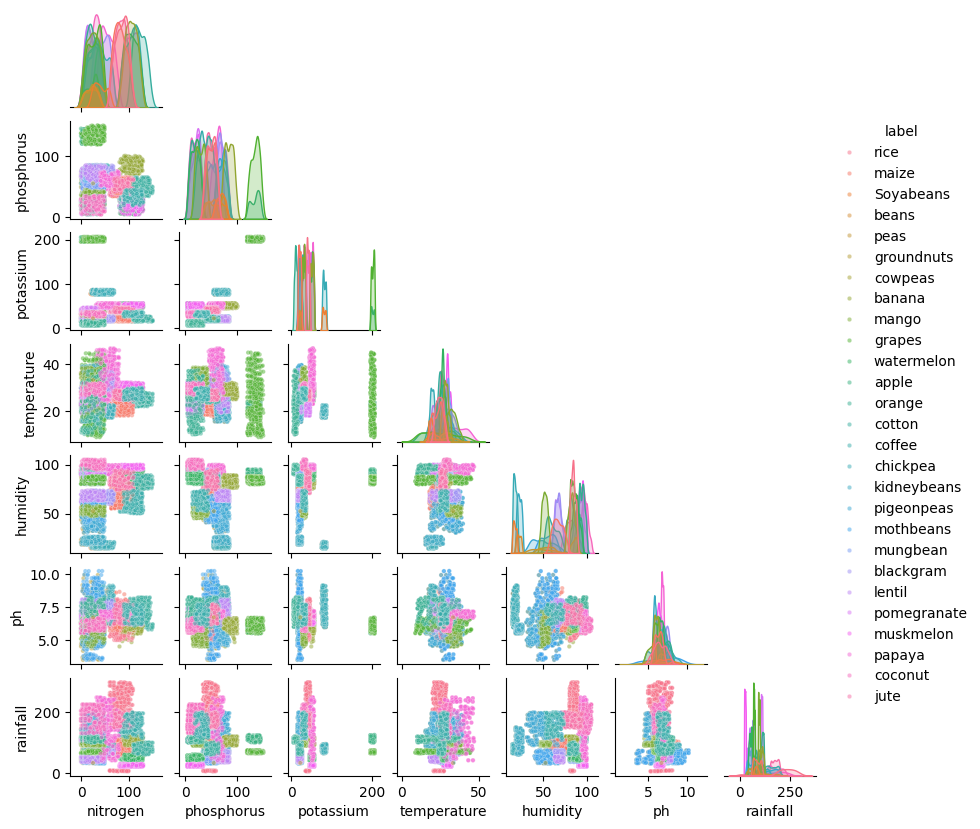

In [47]:
sns.pairplot(
    df,
    hue="label",
    corner=True,
    height=1.2,
    plot_kws={'s': 10, 'alpha': 0.5},   # smaller points
)

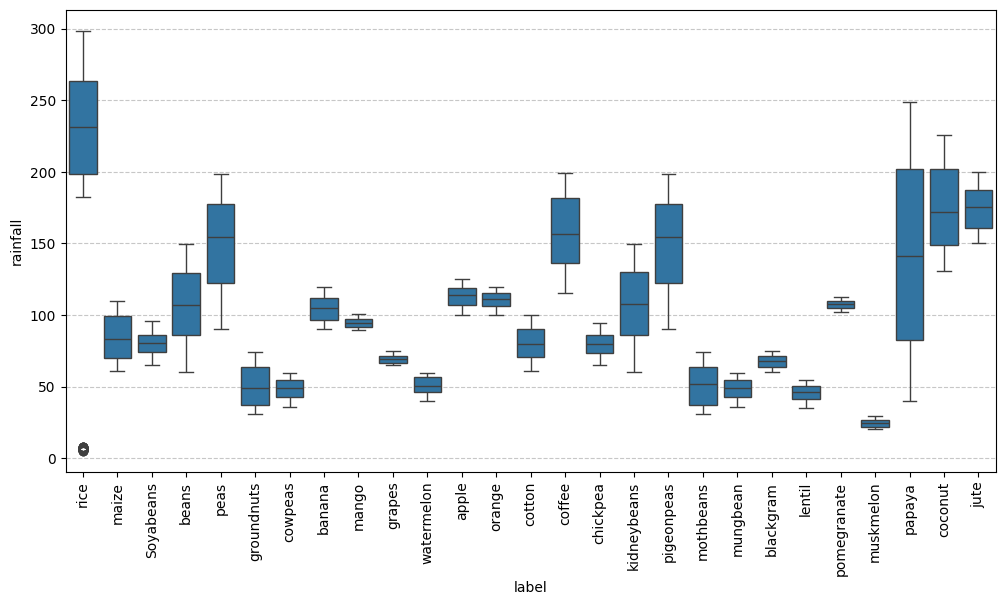

In [48]:
plt.figure(figsize=(12,6))
sns.boxplot(x="label", y="rainfall", data=df)
plt.xticks(rotation=90)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

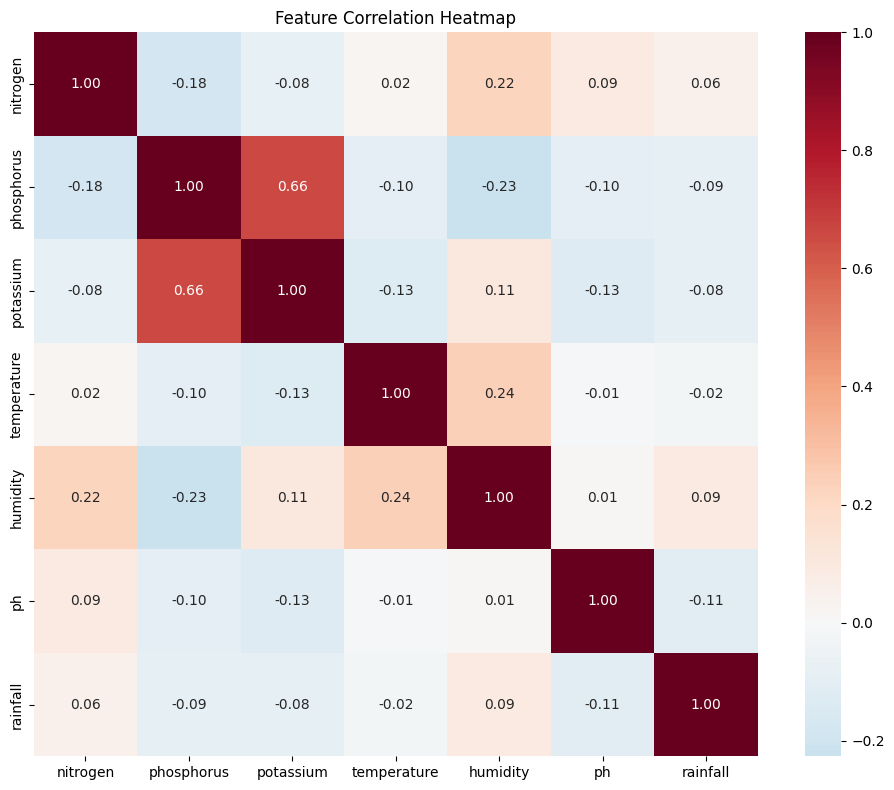

In [49]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing

In [50]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["label"])

In [51]:
X = df.drop("label", axis=1)
y = df["label"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

## Baseline Modeling

In [53]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [54]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

logreg_acc = cross_val_score(logreg, X_train, y_train, cv=cv, scoring='balanced_accuracy').mean()
logreg_f1 = cross_val_score(logreg, X_train, y_train, cv=cv, scoring='f1_weighted').mean()
print("Balanced Accuracy:", logreg_acc)
print("F1 Score:", logreg_f1)

Balanced Accuracy: 0.8342007394578387
F1 Score: 0.881823265787909


In [55]:
knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

knn_acc = cross_val_score(knn, X_train, y_train, cv=cv, scoring='balanced_accuracy').mean()
knn_f1 = cross_val_score(knn, X_train, y_train, cv=cv, scoring='f1_weighted').mean()
print("Balanced Accuracy:", knn_acc)
print("F1 Score:", knn_f1)

Balanced Accuracy: 0.8040564028117292
F1 Score: 0.906632291761194


In [56]:
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

dt_acc = cross_val_score(dt, X_train, y_train, cv=cv, scoring='balanced_accuracy').mean()
dt_f1 = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1_weighted').mean()
print("Balanced Accuracy:", dt_acc)
print("F1 Score:", dt_f1)

Balanced Accuracy: 0.8129637188585089
F1 Score: 0.9054497018298268


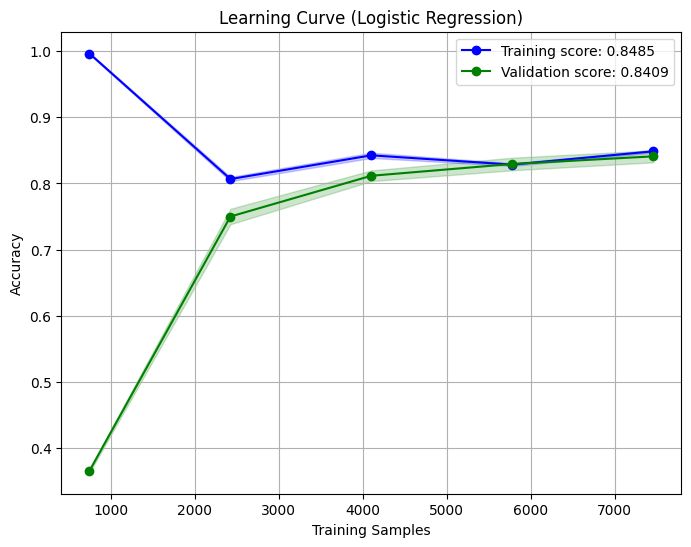

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=logreg,
    X=X,
    y=y,
    cv=cv,
    scoring='balanced_accuracy',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# training curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label=f'Training score: {train_mean[-1]:.4f}')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')

# validation curve
plt.plot(train_sizes, test_mean, 'o-', color='green', label=f'Validation score: {test_mean[-1]:.4f}')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='green')

plt.title('Learning Curve (Logistic Regression)')
plt.xlabel('Training Samples')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

In [58]:
y_pred = logreg.fit(X_train, y_train).predict(X_test)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

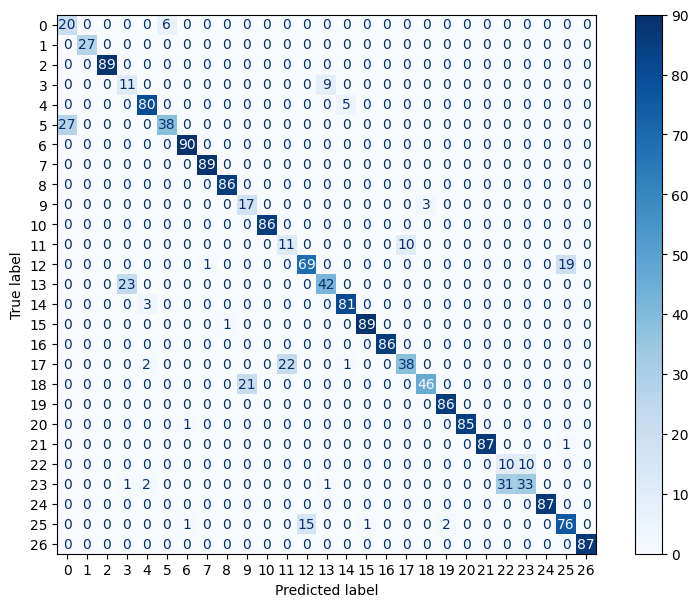

In [59]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=True)
plt.show()

In [60]:
report = classification_report(le.inverse_transform(y_test), le.inverse_transform(y_pred), output_dict=True)

df_report = pd.DataFrame(report).transpose()
df_report.head(total_labels + 4)

,precision,recall,f1-score,support
Soyabeans,0.425532,0.769231,0.547945,26.000000
apple,1.000000,1.000000,1.000000,27.000000
banana,1.000000,1.000000,1.000000,89.000000
beans,0.314286,0.550000,0.400000,20.000000
blackgram,0.919540,0.941176,0.930233,85.000000
chickpea,0.863636,0.584615,0.697248,65.000000
coconut,0.978261,1.000000,0.989011,90.000000
coffee,0.988889,1.000000,0.994413,89.000000
cotton,0.988506,1.000000,0.994220,86.000000
cowpeas,0.447368,0.850000,0.586207,20.000000


In [61]:
print("baseline finished")

baseline finished


## Logistic Regression

In [62]:
# logreg_clf = Pipeline([
#     ('poly', PolynomialFeatures(include_bias=False)),
#     ('scaler', StandardScaler()),
#     ('classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
# ])

# param_grid = {
#     'poly__degree': [1, 2],
#     'classifier__C': [0.01, 0.1, 1, 10, 100],
#     'classifier__penalty': ['l1', 'l2'],
#     'classifier__solver': ['saga']
# }

# grid_search = GridSearchCV(
#     estimator=logreg_clf,
#     param_grid=param_grid,
#     cv=cv,
#     scoring='balanced_accuracy',
#     n_jobs=-1,
#     verbose=1
# )

In [63]:
# grid_search.fit(X_train, y_train)

# print("Best Hyperparameters:", grid_search.best_params_)
# print("Best CV Accuracy:", grid_search.best_score_)

In [64]:
# best_logreg = grid_search.best_estimator_

# y_pred = best_logreg.predict(X_test)

# balanced_acc = balanced_accuracy_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred, average='weighted')

# print("Balanced Accuracy:", balanced_acc)
# print("Weighted F1 Score:", f1)

## K Nearest Neighbors

In [65]:
# knn_clf = Pipeline([
#     ('scaler', StandardScaler()),
#     ('classifier', KNeighborsClassifier())
# ])

# param_grid = {
#     'classifier__n_neighbors': [3, 5, 7, 9],
#     'classifier__weights': ['uniform', 'distance'],
#     'classifier__metric': ['euclidean', 'manhattan', 'minkowski'],
#     'classifier__p': [1, 2]
# }

# grid_search = GridSearchCV(
#     estimator=knn_clf,
#     param_grid=param_grid,
#     cv=cv,
#     scoring='balanced_accuracy',
#     n_jobs=-1,
#     verbose=1
# )

In [66]:
# grid_search.fit(X_train, y_train)

# print("Best Hyperparameters:", grid_search.best_params_)
# print("Best CV Accuracy:", grid_search.best_score_)

In [67]:
# best_knn = grid_search.best_estimator_

# y_pred = best_knn.predict(X_test)

# balanced_acc = balanced_accuracy_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred, average='weighted')

# print("Balanced Accuracy:", balanced_acc)
# print("Weighted F1 Score:", f1)

## Decision Tree

In [68]:
# dt_clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# param_grid = {
#     'max_depth': [3, 5, 7, 9],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(
#     estimator=dt_clf,
#     param_grid=param_grid,
#     cv=cv,
#     scoring='balanced_accuracy',
#     n_jobs=-1,
#     verbose=1
# )

In [69]:
# grid_search.fit(X_train, y_train)

# print("Best Hyperparameters:", grid_search.best_params_)
# print("Best CV Accuracy:", grid_search.best_score_)

In [70]:
# best_dt = grid_search.best_estimator_

# y_pred = best_dt.predict(X_test)

# balanced_acc = balanced_accuracy_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred, average='weighted')

# print("Balanced Accuracy:", balanced_acc)
# print("Weighted F1 Score:", f1)

## Best Baseline Metric

In [71]:
# cm = confusion_matrix(y_test, y_pred)

# fig, ax = plt.subplots(figsize=(10, 7))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_dt.classes_)
# disp.plot(ax=ax, cmap="Blues", colorbar=True)
# plt.show()

In [72]:
# report = classification_report(y_test, y_pred, output_dict=True)

# df_report = pd.DataFrame(report).transpose()
# df_report.head(total_labels + 4)

# Ensemble Methods

## Random Forest

In [73]:
# rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [None, 5, 10],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['log2', 'sqrt']
# }

# grid_search = GridSearchCV(
#     estimator=rf_clf,
#     param_grid=param_grid,
#     cv=cv,
#     scoring='balanced_accuracy',
#     n_jobs=-1,
#     verbose=1
# )

In [74]:
# grid_search.fit(X_train, y_train)

# print("Best Hyperparameters:", grid_search.best_params_)
# print("Best CV Accuracy:", grid_search.best_score_)

In [75]:
# best_dt = grid_search.best_estimator_

# y_pred = best_dt.predict(X_test)

# balanced_acc = balanced_accuracy_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred, average='weighted')

# print("Balanced Accuracy:", balanced_acc)
# print("Weighted F1 Score:", f1)